In [ ]:
# Install required libraries (run once)
!pip install shap plotly kaleido --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.1 MB/s eta 0:00:00


In [ ]:
# ─── Core Libraries ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

# ─── ML & Preprocessing ───────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)

# ─── PyTorch ──────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ─── XAI ──────────────────────────────────────────────────────────
import shap

# ─── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded | Device: {DEVICE}')

✅ Libraries loaded | Device: cpu


In [ ]:

df = pd.read_csv('CFRP_dataset.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (8080, 18)


,Sample_ID,Data_Type,Condition,Damage_Type,Vent_Holes,Fiber_Volume_Fraction,Void_Content,Fiber_Orientation_Degree,LBP_Feature_1,LBP_Feature_2,Texture_Contrast,Average_Temperature,Temperature_Variance,Defect_Density,Crack_Length_mm,Fracture_Toughness,Tensile_Strength,Structural_Integrity_Class
0,1,Thermograph,Mixed,NaN,4,0.566,0.058,3.28,0.984,0.389,0.313,26.60,1.79,0.128,2.310,31.30,372.62,Medium
1,2,C-scan (BVID with Holes),Damaged,BVID,5,0.601,0.050,18.99,0.420,0.538,0.627,74.07,6.47,0.154,2.983,49.43,413.52,Medium
2,3,C-scan (Pristine with Holes),Pristine,NaN,3,0.693,0.069,63.80,0.926,0.484,0.358,58.57,12.74,0.035,0.739,34.65,497.68,Medium
3,4,C-scan (BVID with Holes),Damaged,BVID,6,0.501,0.047,52.88,0.993,0.928,0.265,32.47,1.51,0.130,2.673,31.30,505.09,Medium
4,5,C-scan (Pristine with Holes),Pristine,NaN,2,0.502,0.010,51.37,0.378,0.352,0.699,29.69,6.09,0.018,0.413,59.72,515.48,High
5,6,Thermograph,Mixed,NaN,6,0.454,0.064,39.46,0.887,0.497,0.509,115.49,0.51,0.033,0.824,39.62,624.25,Medium
6,7,C-scan (BVID with Holes),Damaged,BVID,2,0.513,0.026,86.12,0.106,0.929,0.878,88.32,2.54,0.109,2.979,37.17,476.49,Medium
7,8,Thermograph,Mixed,NaN,4,0.498,0.070,16.76,0.575,0.555,0.471,109.64,13.31,0.102,1.287,33.81,527.65,Medium
8,9,C-scan (Pristine with Holes),Pristine,NaN,6,0.532,0.072,1.32,0.394,0.367,0.887,88.07,5.24,0.031,0.234,23.46,540.22,Low
9,10,C-scan (BVID with Holes),Damaged,BVID,6,0.546,0.032,32.02,0.450,0.106,0.278,114.52,11.08,0.188,3.322,35.87,470.54,Medium


In [ ]:
# ── Basic Statistics ──────────────────────────────────────────────
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()
print('\n')
print('='*60)
print('MISSING VALUES')
print('='*60)
print(df.isnull().sum())
print('\n')
print('='*60)
print('DESCRIPTIVE STATISTICS')
print('='*60)
df.describe().round(3)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sample_ID                   8080 non-null   int64  
 1   Data_Type                   8080 non-null   object 
 2   Condition                   8080 non-null   object 
 3   Damage_Type                 4080 non-null   object 
 4   Vent_Holes                  8080 non-null   int64  
 5   Fiber_Volume_Fraction       8080 non-null   float64
 6   Void_Content                8080 non-null   float64
 7   Fiber_Orientation_Degree    8080 non-null   float64
 8   LBP_Feature_1               8080 non-null   float64
 9   LBP_Feature_2               8080 non-null   float64
 10  Texture_Contrast            8080 non-null   float64
 11  Average_Temperature         8080 non-null   float64
 12  Temperature_Variance        8080 non-null   float64
 13  Defect_Density      

,Sample_ID,Vent_Holes,Fiber_Volume_Fraction,Void_Content,Fiber_Orientation_Degree,LBP_Feature_1,LBP_Feature_2,Texture_Contrast,Average_Temperature,Temperature_Variance,Defect_Density,Crack_Length_mm,Fracture_Toughness,Tensile_Strength
count,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000,8080.000
mean,4040.500,4.021,0.574,0.045,44.669,0.552,0.547,0.551,72.663,7.772,0.087,1.878,39.928,623.863
std,2332.639,1.424,0.072,0.020,25.820,0.261,0.261,0.202,27.351,4.188,0.053,1.323,11.640,158.629
min,1.000,2.000,0.450,0.010,0.040,0.100,0.100,0.200,25.020,0.500,0.010,0.101,20.010,350.000
25%,2020.750,3.000,0.512,0.028,22.120,0.326,0.321,0.376,49.100,4.170,0.038,0.730,29.740,486.148
50%,4040.500,4.000,0.575,0.045,44.855,0.550,0.543,0.554,73.310,7.810,0.086,1.624,39.890,622.365
75%,6060.250,5.000,0.636,0.063,66.620,0.778,0.769,0.728,96.060,11.420,0.130,2.882,50.020,760.345
max,8080.000,6.000,0.700,0.080,90.000,1.000,1.000,0.900,120.000,14.990,0.200,4.999,60.000,900.000


In [ ]:
# ── Categorical Column Distributions ─────────────────────────────
cat_cols = ['Data_Type', 'Condition', 'Damage_Type', 'Structural_Integrity_Class']
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())


Data_Type:
Data_Type
Thermograph                     2765
C-scan (BVID with Holes)        2696
C-scan (Pristine with Holes)    2619
Name: count, dtype: int64

Condition:
Condition
Mixed       2765
Damaged     2696
Pristine    2619
Name: count, dtype: int64

Damage_Type:
Damage_Type
BVID               2696
Thermal Anomaly    1384
Name: count, dtype: int64

Structural_Integrity_Class:
Structural_Integrity_Class
Medium    4603
Low       2069
High      1408
Name: count, dtype: int64


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Tensile Strength & Fracture Toughness Distributions ──────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Tensile Strength Distribution (MPa)',
        'Fracture Toughness Distribution (MPa√m)'
    )
)

# Tensile Strength
fig.add_trace(
    go.Histogram(
        x=df['Tensile_Strength'],
        nbinsx=60,
        marker=dict(
            color='steelblue',
            line=dict(color='black', width=1)   # 🔹 ADD BORDER
        ),
        opacity=0.8,
        name='Tensile Strength'
    ),
    row=1, col=1
)

# Fracture Toughness
fig.add_trace(
    go.Histogram(
        x=df['Fracture_Toughness'],
        nbinsx=60,
        marker=dict(
            color='coral',
            line=dict(color='black', width=1)   # 🔹 ADD BORDER
        ),
        opacity=0.8,
        name='Fracture Toughness'
    ),
    row=1, col=2
)

# Layout
fig.update_layout(
    title='Target Variable Distributions',
    height=450,
    template='plotly_white',
    showlegend=False,
    bargap=0.05   # 🔹 small gap between bars (optional, improves clarity)
)

fig.show()

In [ ]:
# ── Structural Integrity Class Distribution ───────────────────────
class_counts = df['Structural_Integrity_Class'].value_counts().reset_index()
class_counts.columns = ['Class', 'Count']

fig = px.bar(
    class_counts, x='Class', y='Count',
    color='Class',
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'},
    title='Structural Integrity Class Distribution',
    text='Count', template='plotly_white'
)
fig.update_traces(textposition='outside')
fig.update_layout(height=400, showlegend=False)
fig.show()

In [ ]:
# ── Box Plots: Key Features by Condition ─────────────────────────
num_features = [
    'Fiber_Volume_Fraction', 'Void_Content', 'Fiber_Orientation_Degree',
    'Defect_Density', 'Crack_Length_mm', 'Fracture_Toughness',
    'Tensile_Strength', 'Average_Temperature'
]

fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=num_features,
    vertical_spacing=0.15
)

condition_colors = {'Pristine': '#27ae60', 'Damaged': '#e74c3c', 'Mixed': '#3498db'}

for idx, feat in enumerate(num_features):
    row = idx // 4 + 1
    col = idx % 4 + 1
    for cond, color in condition_colors.items():
        subset = df[df['Condition'] == cond][feat]
        fig.add_trace(
            go.Box(
                y=subset, name=cond, legendgroup=cond,
                showlegend=(idx == 0),
                marker_color=color, boxmean='sd'
            ), row=row, col=col
        )

fig.update_layout(
    title='Feature Distributions by Material Condition (Pristine / Damaged / Mixed)',
    height=700, template='plotly_white',
    legend=dict(orientation='h', y=-0.08)
)
fig.show()

In [ ]:
# ── Violin Plot: Tensile Strength by Condition & Integrity Class ──
fig = px.violin(
    df, x='Structural_Integrity_Class', y='Tensile_Strength',
    color='Condition', box=True, points='outliers',
    color_discrete_map={
        'Pristine': '#27ae60', 'Damaged': '#e74c3c', 'Mixed': '#3498db'
    },
    category_orders={'Structural_Integrity_Class': ['Low', 'Medium', 'High']},
    title='Tensile Strength Distribution by Integrity Class and Condition',
    template='plotly_white', height=500
)
fig.show()

In [ ]:
# ── Full Correlation Heatmap (Interactive) ────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Sample_ID'])
corr_matrix = numeric_cols.corr().round(3)

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.columns.tolist(),
    colorscale='RdBu_r',
    zmid=0,
    text=corr_matrix.values.round(2),
    texttemplate='%{text}',
    textfont={'size': 10},
    hoverongaps=False,
    colorbar=dict(title='Correlation')
))

fig.update_layout(
    title='Interactive Correlation Heatmap — CFRP Features',
    height=650, width=850,
    template='plotly_white',
    xaxis=dict(tickangle=-40),
)
fig.show()

# Print top correlations with Tensile Strength
print('\nTop Correlations with Tensile Strength:')
ts_corr = corr_matrix['Tensile_Strength'].drop('Tensile_Strength').sort_values(key=abs, ascending=False)
print(ts_corr.to_string())


Top Correlations with Tensile Strength:
Fracture_Toughness          0.020
Defect_Density             -0.017
Fiber_Orientation_Degree   -0.014
Vent_Holes                 -0.012
Crack_Length_mm            -0.011
Average_Temperature         0.008
Void_Content               -0.007
Fiber_Volume_Fraction      -0.006
LBP_Feature_1              -0.005
LBP_Feature_2              -0.005
Texture_Contrast            0.004
Temperature_Variance        0.000


In [ ]:
# ── Interactive Scatter Matrix ─────────────────────────────────────
key_features = [
    'Fiber_Volume_Fraction', 'Void_Content', 'Defect_Density',
    'Crack_Length_mm', 'Fracture_Toughness', 'Tensile_Strength'
]

fig = px.scatter_matrix(
    df[key_features + ['Structural_Integrity_Class']],
    dimensions=key_features,
    color='Structural_Integrity_Class',
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'},
    opacity=0.4,
    title='Scatter Matrix — Key CFRP Features colored by Structural Integrity Class',
    height=800
)
fig.update_traces(marker=dict(size=2.5))
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
# ── 3D Scatter: Fiber Volume vs Defect Density vs Tensile Strength ─
fig = px.scatter_3d(
    df.sample(2000, random_state=SEED),
    x='Fiber_Volume_Fraction',
    y='Defect_Density',
    z='Tensile_Strength',
    color='Structural_Integrity_Class',
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'},
    opacity=0.7, size_max=4,
    title='3D View: Fiber Volume Fraction vs Defect Density vs Tensile Strength',
    template='plotly_white', height=600
)
fig.show()

In [ ]:
# ── Parallel Coordinates Plot: Multi-feature Exploration ──────────
df_sample = df.sample(1500, random_state=SEED).copy()
class_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_sample['Class_Num'] = df_sample['Structural_Integrity_Class'].map(class_map)

fig = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=df_sample['Class_Num'],
            colorscale=[[0, '#e74c3c'], [0.5, '#f39c12'], [1, '#27ae60']],
            showscale=True,
            colorbar=dict(
                tickvals=[0, 1, 2], ticktext=['Low', 'Medium', 'High'],
                title='Integrity'
            )
        ),
        dimensions=[
            dict(label='Fiber Vol Frac', values=df_sample['Fiber_Volume_Fraction'],
                 range=[0.4, 0.75]),
            dict(label='Void Content', values=df_sample['Void_Content'],
                 range=[0, 0.09]),
            dict(label='Fiber Orientation°', values=df_sample['Fiber_Orientation_Degree'],
                 range=[0, 90]),
            dict(label='Defect Density', values=df_sample['Defect_Density'],
                 range=[0, 0.2]),
            dict(label='Crack Length (mm)', values=df_sample['Crack_Length_mm'],
                 range=[0, 6]),
            dict(label='Fracture Toughness', values=df_sample['Fracture_Toughness'],
                 range=[20, 65]),
            dict(label='Tensile Strength (MPa)', values=df_sample['Tensile_Strength'],
                 range=[300, 950]),
        ]
    )
)

fig.update_layout(
    title='Parallel Coordinates — Multi-feature Structural Integrity Analysis<br><sup>Click and drag on axes to filter ranges interactively</sup>',
    height=500, template='plotly_white'
)
fig.show()

In [ ]:
import plotly.express as px

# 🔹 Make a copy (safe practice)
df_clean = df.copy()

# 🔹 Fill missing values in hierarchy columns
df_clean['Condition'] = df_clean['Condition'].fillna('Unknown')
df_clean['Damage_Type'] = df_clean['Damage_Type'].fillna('Unknown')
df_clean['Structural_Integrity_Class'] = df_clean['Structural_Integrity_Class'].fillna('Unknown')

# ── Sunburst: Hierarchical View of Data Composition ───────────────
fig = px.sunburst(
    df_clean,
    path=['Condition', 'Damage_Type', 'Structural_Integrity_Class'],
    color='Condition',
    color_discrete_map={
        'Pristine': '#27ae60',
        'Damaged': '#e74c3c',
        'Mixed': '#3498db',
        'Unknown': '#95a5a6'   # 🔹 added for missing values
    },
    title='Hierarchical Data Composition: Condition → Damage → Integrity Class',
    height=550
)

fig.update_traces(
    textinfo='label+percent entry',
    insidetextorientation='radial'
)

fig.show()

In [ ]:
# ── Scatter: Crack Length vs Fracture Toughness (colored by Tensile Strength) ─
fig = px.scatter(
    df.sample(2000, random_state=SEED),
    x='Crack_Length_mm', y='Fracture_Toughness',
    color='Tensile_Strength',
    color_continuous_scale='Viridis',
    facet_col='Structural_Integrity_Class',
    category_orders={'Structural_Integrity_Class': ['Low', 'Medium', 'High']},
    opacity=0.7,
    title='Crack Length vs Fracture Toughness (color = Tensile Strength) by Integrity Class',
    template='plotly_white', height=420
)
fig.show()

In [ ]:
# ── Animated Bubble: Temperature vs Tensile Strength ─────────────
df_agg = df.groupby(['Structural_Integrity_Class', 'Condition']).agg(
    Avg_Temp=('Average_Temperature', 'mean'),
    Avg_Tensile=('Tensile_Strength', 'mean'),
    Avg_Defect=('Defect_Density', 'mean'),
    Count=('Sample_ID', 'count')
).reset_index()

fig = px.scatter(
    df_agg,
    x='Avg_Temp', y='Avg_Tensile',
    size='Count', color='Structural_Integrity_Class',
    symbol='Condition',
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'},
    text='Structural_Integrity_Class',
    title='Average Temperature vs Tensile Strength by Group (bubble = sample count)',
    labels={'Avg_Temp': 'Avg Temperature (°C)', 'Avg_Tensile': 'Avg Tensile Strength (MPa)'},
    template='plotly_white', height=480, size_max=50
)
fig.update_traces(textposition='top center')
fig.show()

In [ ]:
# ── Feature Engineering ───────────────────────────────────────────
df_ml = df.copy()

# Domain-driven composite features
df_ml['Strength_to_Defect_Ratio']  = df_ml['Tensile_Strength'] / (df_ml['Defect_Density'] + 1e-5)
df_ml['Toughness_per_Crack']       = df_ml['Fracture_Toughness'] / (df_ml['Crack_Length_mm'] + 1e-5)
df_ml['Fiber_Quality_Index']       = df_ml['Fiber_Volume_Fraction'] / (df_ml['Void_Content'] + 1e-5)
df_ml['Damage_Severity_Index']     = df_ml['Defect_Density'] * df_ml['Crack_Length_mm']
df_ml['Thermal_Instability']       = df_ml['Average_Temperature'] * df_ml['Temperature_Variance']
df_ml['Composite_Quality_Score']   = (df_ml['Fiber_Volume_Fraction'] - df_ml['Void_Content']
                                       - df_ml['Defect_Density'])

# ── Encode Categorical Variables ───────────────────────────────────
# One-hot encode Data_Type, Condition, Damage_Type
df_ml = pd.get_dummies(df_ml, columns=['Data_Type', 'Condition', 'Damage_Type'], drop_first=False)

# Encode target class
class_encoder = LabelEncoder()
df_ml['Integrity_Label'] = class_encoder.fit_transform(df_ml['Structural_Integrity_Class'])
print('Class mapping:', dict(zip(class_encoder.classes_, class_encoder.transform(class_encoder.classes_))))

# Drop non-feature columns
drop_cols = ['Sample_ID', 'Structural_Integrity_Class']
df_ml = df_ml.drop(columns=drop_cols)

print(f'\nFinal feature set shape: {df_ml.shape}')
print(f'Columns: {list(df_ml.columns)}')

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Final feature set shape: (8080, 28)
Columns: ['Vent_Holes', 'Fiber_Volume_Fraction', 'Void_Content', 'Fiber_Orientation_Degree', 'LBP_Feature_1', 'LBP_Feature_2', 'Texture_Contrast', 'Average_Temperature', 'Temperature_Variance', 'Defect_Density', 'Crack_Length_mm', 'Fracture_Toughness', 'Tensile_Strength', 'Strength_to_Defect_Ratio', 'Toughness_per_Crack', 'Fiber_Quality_Index', 'Damage_Severity_Index', 'Thermal_Instability', 'Composite_Quality_Score', 'Data_Type_C-scan (BVID with Holes)', 'Data_Type_C-scan (Pristine with Holes)', 'Data_Type_Thermograph', 'Condition_Damaged', 'Condition_Mixed', 'Condition_Pristine', 'Damage_Type_BVID', 'Damage_Type_Thermal Anomaly', 'Integrity_Label']


In [ ]:
# ── Define Feature Sets & Targets ────────────────────────────────
TARGET_REG_TS  = 'Tensile_Strength'
TARGET_REG_FT  = 'Fracture_Toughness'
TARGET_CLF     = 'Integrity_Label'

FEATURE_COLS = [c for c in df_ml.columns if c not in
                [TARGET_REG_TS, TARGET_REG_FT, TARGET_CLF]]

X = df_ml[FEATURE_COLS].values.astype(np.float32)
y_ts  = df_ml[TARGET_REG_TS].values.astype(np.float32)
y_ft  = df_ml[TARGET_REG_FT].values.astype(np.float32)
y_clf = df_ml[TARGET_CLF].values.astype(np.int64)

print(f'Feature matrix X: {X.shape}')
print(f'Tensile Strength y: {y_ts.shape}')
print(f'Fracture Toughness y: {y_ft.shape}')
print(f'Integrity Class y: {y_clf.shape}')

Feature matrix X: (8080, 25)
Tensile Strength y: (8080,)
Fracture Toughness y: (8080,)
Integrity Class y: (8080,)


In [ ]:
# ── Train/Val/Test Split ──────────────────────────────────────────
# 70% train | 15% val | 15% test
X_train, X_temp, y_ts_train, y_ts_temp = train_test_split(X, y_ts, test_size=0.3, random_state=SEED)
X_val, X_test, y_ts_val, y_ts_test     = train_test_split(X_temp, y_ts_temp, test_size=0.5, random_state=SEED)

_, _, y_ft_train, y_ft_temp = train_test_split(X, y_ft, test_size=0.3, random_state=SEED)
_, _, y_ft_val, y_ft_test   = train_test_split(X_temp, y_ft_temp, test_size=0.5, random_state=SEED)

_, _, y_clf_train, y_clf_temp = train_test_split(X, y_clf, test_size=0.3, random_state=SEED)
_, _, y_clf_val, y_clf_test   = train_test_split(X_temp, y_clf_temp, test_size=0.5, random_state=SEED)

# ── Feature Scaling ───────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Target scalers for regression (helps training)
ts_scaler = StandardScaler()
y_ts_train_s = ts_scaler.fit_transform(y_ts_train.reshape(-1,1)).flatten().astype(np.float32)
y_ts_val_s   = ts_scaler.transform(y_ts_val.reshape(-1,1)).flatten().astype(np.float32)

ft_scaler = StandardScaler()
y_ft_train_s = ft_scaler.fit_transform(y_ft_train.reshape(-1,1)).flatten().astype(np.float32)
y_ft_val_s   = ft_scaler.transform(y_ft_val.reshape(-1,1)).flatten().astype(np.float32)

print(f'Train: {X_train_s.shape} | Val: {X_val_s.shape} | Test: {X_test_s.shape}')

# ── Convert to PyTorch Tensors ────────────────────────────────────
def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Regression loaders (Tensile Strength)
ts_train_loader = make_loader(X_train_s, y_ts_train_s)
ts_val_loader   = make_loader(X_val_s,   y_ts_val_s,   shuffle=False)

# Regression loaders (Fracture Toughness)
ft_train_loader = make_loader(X_train_s, y_ft_train_s)
ft_val_loader   = make_loader(X_val_s,   y_ft_val_s,   shuffle=False)

# Classification loaders
clf_train_loader = make_loader(X_train_s, y_clf_train.astype(np.int64))
clf_val_loader   = make_loader(X_val_s,   y_clf_val.astype(np.int64), shuffle=False)

print('DataLoaders ready')

Train: (5656, 25) | Val: (1212, 25) | Test: (1212, 25)
DataLoaders ready


In [ ]:
class MaterialsDNN(nn.Module):
    """
    Deep Neural Network for CFRP Material Property Prediction.

    Architecture:
      Input → [Linear → BN → GELU → Dropout] × N → Output
      Residual connections between same-size hidden layers for better gradient flow.
    """
    def __init__(self, input_dim: int, output_dim: int,
                 hidden_dims: list = [256, 256, 128, 64],
                 dropout: float = 0.3,
                 task: str = 'regression'):
        super().__init__()
        self.task = task

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            ])
            in_dim = h_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.output_layer      = nn.Linear(in_dim, output_dim)

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)


# Instantiate models
INPUT_DIM = X_train_s.shape[1]

model_ts  = MaterialsDNN(INPUT_DIM, 1,  task='regression').to(DEVICE)   # Tensile Strength
model_ft  = MaterialsDNN(INPUT_DIM, 1,  task='regression').to(DEVICE)   # Fracture Toughness
model_clf = MaterialsDNN(INPUT_DIM, 3,  task='classification',           # Integrity Class
                         hidden_dims=[256, 128, 64]).to(DEVICE)

total_params = sum(p.numel() for p in model_ts.parameters() if p.requires_grad)
print(f'Model Architecture:\n{model_ts}')
print(f'\nTrainable Parameters: {total_params:,}')
print(f'Input Features: {INPUT_DIM}')

Model Architecture:
MaterialsDNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=25, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): GELU(approximate='none')
    (15): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear

In [ ]:
def train_model(model, train_loader, val_loader, task='regression',
                epochs=80, lr=1e-3, patience=12):

    import torch
    import torch.nn as nn
    import torch.optim as optim

    """
    General training loop with:
      - Adam optimizer + ReduceLROnPlateau scheduler
      - Early stopping
      - Train/Val loss tracking
    """

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # ❌ removed verbose (causing error)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    criterion = nn.MSELoss() if task == 'regression' else nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):

        # ── Train ─────────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()
            out = model(X_batch)

            if task == 'regression':
                loss = criterion(out.squeeze(), y_batch)
            else:
                loss = criterion(out, y_batch)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * len(X_batch)

        # ── Validate ───────────────────────────────────────────────
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                out = model(X_batch)

                if task == 'regression':
                    loss = criterion(out.squeeze(), y_batch)
                else:
                    loss = criterion(out, y_batch)

                val_loss += loss.item() * len(X_batch)

        # ── Normalize Loss ─────────────────────────────────────────
        train_loss /= len(train_loader.dataset)
        val_loss   /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # 🔹 Manual LR tracking (replacement for verbose)
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        if new_lr != old_lr:
            print(f"🔻 LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        # ── Early Stopping Logic ───────────────────────────────────
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # ── Logging ────────────────────────────────────────────────
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.5f} | '
                  f'Val Loss: {val_loss:.5f} | LR: {new_lr:.6f}')

        if no_improve >= patience:
            print(f'\n⏹ Early stopping at epoch {epoch}')
            break

    # ── Load Best Model ───────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f'Best Val Loss: {best_val:.5f}')
    return history

In [ ]:
# ── Train Model 1: Tensile Strength Regression ───────────────────
print('='*55)
print('MODEL 1: Tensile Strength Regression')
print('='*55)
hist_ts = train_model(model_ts, ts_train_loader, ts_val_loader, task='regression', epochs=80)

MODEL 1: Tensile Strength Regression
Epoch  10 | Train Loss: 0.10804 | Val Loss: 0.02947 | LR: 0.001000
Epoch  20 | Train Loss: 0.10051 | Val Loss: 0.03337 | LR: 0.001000
🔻 LR reduced: 0.001000 → 0.000500
Epoch  30 | Train Loss: 0.08572 | Val Loss: 0.03805 | LR: 0.000500
🔻 LR reduced: 0.000500 → 0.000250
🔻 LR reduced: 0.000250 → 0.000125
Epoch  40 | Train Loss: 0.08621 | Val Loss: 0.03628 | LR: 0.000125
Epoch  50 | Train Loss: 0.08101 | Val Loss: 0.03140 | LR: 0.000125
🔻 LR reduced: 0.000125 → 0.000063
🔻 LR reduced: 0.000063 → 0.000031

⏹ Early stopping at epoch 57
Best Val Loss: 0.01710


In [ ]:
# ── Train Model 2: Fracture Toughness Regression ─────────────────
print('='*55)
print('MODEL 2: Fracture Toughness Regression')
print('='*55)
hist_ft = train_model(model_ft, ft_train_loader, ft_val_loader, task='regression', epochs=80)

MODEL 2: Fracture Toughness Regression
Epoch  10 | Train Loss: 0.95651 | Val Loss: 0.84284 | LR: 0.001000
Epoch  20 | Train Loss: 0.76389 | Val Loss: 0.61067 | LR: 0.001000
Epoch  30 | Train Loss: 0.58161 | Val Loss: 0.40268 | LR: 0.001000
Epoch  40 | Train Loss: 0.42340 | Val Loss: 0.23106 | LR: 0.001000
Epoch  50 | Train Loss: 0.31148 | Val Loss: 0.15721 | LR: 0.001000
Epoch  60 | Train Loss: 0.25167 | Val Loss: 0.13045 | LR: 0.001000
🔻 LR reduced: 0.001000 → 0.000500
Epoch  70 | Train Loss: 0.20704 | Val Loss: 0.11902 | LR: 0.000500
🔻 LR reduced: 0.000500 → 0.000250
Epoch  80 | Train Loss: 0.19019 | Val Loss: 0.11590 | LR: 0.000250
Best Val Loss: 0.08906


In [ ]:
# ── Train Model 3: Structural Integrity Classification ────────────
print('='*55)
print('MODEL 3: Structural Integrity Classification')
print('='*55)
hist_clf = train_model(model_clf, clf_train_loader, clf_val_loader, task='classification', epochs=80)

MODEL 3: Structural Integrity Classification
Epoch  10 | Train Loss: 0.83100 | Val Loss: 0.78606 | LR: 0.001000
Epoch  20 | Train Loss: 0.75641 | Val Loss: 0.71211 | LR: 0.001000
Epoch  30 | Train Loss: 0.67724 | Val Loss: 0.64172 | LR: 0.001000
Epoch  40 | Train Loss: 0.60316 | Val Loss: 0.54715 | LR: 0.001000
Epoch  50 | Train Loss: 0.51664 | Val Loss: 0.45961 | LR: 0.001000
Epoch  60 | Train Loss: 0.46242 | Val Loss: 0.38370 | LR: 0.001000
Epoch  70 | Train Loss: 0.39657 | Val Loss: 0.31579 | LR: 0.001000
Epoch  80 | Train Loss: 0.35370 | Val Loss: 0.26541 | LR: 0.001000
Best Val Loss: 0.26541


In [ ]:
# ── Training Curves (Interactive) ────────────────────────────────
def plot_training_curves(histories: dict):
    fig = make_subplots(rows=1, cols=len(histories),
                        subplot_titles=list(histories.keys()))
    colors = [('#3498db', '#e74c3c'), ('#27ae60', '#f39c12'), ('#9b59b6', '#e67e22')]
    for idx, (name, hist) in enumerate(histories.items()):
        c_train, c_val = colors[idx]
        epochs = list(range(1, len(hist['train_loss']) + 1))
        fig.add_trace(go.Scatter(x=epochs, y=hist['train_loss'], mode='lines',
                                  name=f'{name} Train', line=dict(color=c_train, width=2)),
                      row=1, col=idx+1)
        fig.add_trace(go.Scatter(x=epochs, y=hist['val_loss'], mode='lines',
                                  name=f'{name} Val', line=dict(color=c_val, width=2, dash='dash')),
                      row=1, col=idx+1)

    fig.update_layout(title='Training & Validation Loss Curves',
                      height=400, template='plotly_white')
    fig.show()

plot_training_curves({
    'Tensile Strength': hist_ts,
    'Fracture Toughness': hist_ft,
    'Integrity Class': hist_clf
})

In [ ]:
def predict_regression(model, X, scaler=None):
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X).to(DEVICE)).cpu().numpy().flatten()
    if scaler is not None:
        preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    return preds

def predict_classification(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X).to(DEVICE))
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
    return preds


# ── Regression Evaluation ─────────────────────────────────────────
ts_pred  = predict_regression(model_ts,  X_test_s, ts_scaler)
ft_pred  = predict_regression(model_ft,  X_test_s, ft_scaler)
clf_pred = predict_classification(model_clf, X_test_s)

print('='*55)
print('TENSILE STRENGTH (Regression)')
print('='*55)
ts_r2   = r2_score(y_ts_test, ts_pred)
ts_rmse = np.sqrt(mean_squared_error(y_ts_test, ts_pred))
ts_mae  = mean_absolute_error(y_ts_test, ts_pred)
print(f'  R² Score : {ts_r2:.4f}')
print(f'  RMSE     : {ts_rmse:.3f} MPa')
print(f'  MAE      : {ts_mae:.3f} MPa')

print('\n' + '='*55)
print('FRACTURE TOUGHNESS (Regression)')
print('='*55)
ft_r2   = r2_score(y_ft_test, ft_pred)
ft_rmse = np.sqrt(mean_squared_error(y_ft_test, ft_pred))
ft_mae  = mean_absolute_error(y_ft_test, ft_pred)
print(f'  R² Score : {ft_r2:.4f}')
print(f'  RMSE     : {ft_rmse:.3f} MPa√m')
print(f'  MAE      : {ft_mae:.3f} MPa√m')

print('\n' + '='*55)
print('STRUCTURAL INTEGRITY CLASS (Classification)')
print('='*55)
print(classification_report(y_clf_test, clf_pred,
                             target_names=class_encoder.classes_))

TENSILE STRENGTH (Regression)
  R² Score : 0.9804
  RMSE     : 22.227 MPa
  MAE      : 16.008 MPa

FRACTURE TOUGHNESS (Regression)
  R² Score : 0.9037
  RMSE     : 3.578 MPa√m
  MAE      : 2.494 MPa√m

STRUCTURAL INTEGRITY CLASS (Classification)
              precision    recall  f1-score   support

        High       0.76      0.94      0.84       209
         Low       0.93      0.85      0.89       299
      Medium       0.92      0.89      0.90       704

    accuracy                           0.89      1212
   macro avg       0.87      0.89      0.88      1212
weighted avg       0.90      0.89      0.89      1212



In [ ]:
# ── Predicted vs Actual: Tensile Strength ────────────────────────
sample_idx = np.random.choice(len(y_ts_test), 800, replace=False)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[
                        'Tensile Strength: Predicted vs Actual',
                        'Fracture Toughness: Predicted vs Actual'
                    ])

# Tensile Strength
fig.add_trace(go.Scatter(
    x=y_ts_test[sample_idx], y=ts_pred[sample_idx],
    mode='markers', marker=dict(color='steelblue', size=4, opacity=0.6),
    name='TS Predictions'
), row=1, col=1)
lim = [min(y_ts_test), max(y_ts_test)]
fig.add_trace(go.Scatter(x=lim, y=lim, mode='lines',
    line=dict(color='red', dash='dash'), name='Perfect Fit'), row=1, col=1)

# Fracture Toughness
fig.add_trace(go.Scatter(
    x=y_ft_test[sample_idx], y=ft_pred[sample_idx],
    mode='markers', marker=dict(color='coral', size=4, opacity=0.6),
    name='FT Predictions'
), row=1, col=2)
lim2 = [min(y_ft_test), max(y_ft_test)]
fig.add_trace(go.Scatter(x=lim2, y=lim2, mode='lines',
    line=dict(color='red', dash='dash'), showlegend=False), row=1, col=2)

fig.update_layout(
    title=f'Model Predictions vs Ground Truth | TS R²={ts_r2:.3f} | FT R²={ft_r2:.3f}',
    height=450, template='plotly_white'
)
fig.update_xaxes(title_text='Actual', row=1, col=1)
fig.update_yaxes(title_text='Predicted', row=1, col=1)
fig.update_xaxes(title_text='Actual', row=1, col=2)
fig.update_yaxes(title_text='Predicted', row=1, col=2)
fig.show()

In [ ]:
# ── Confusion Matrix (Classification) ────────────────────────────
cm = confusion_matrix(y_clf_test, clf_pred)
class_names = class_encoder.classes_

fig = go.Figure(data=go.Heatmap(
    z=cm, x=class_names, y=class_names,
    colorscale='Blues',
    text=cm, texttemplate='<b>%{text}</b>', textfont=dict(size=16),
    showscale=True
))
fig.update_layout(
    title=f' Confusion Matrix — Structural Integrity Classification | Acc={accuracy_score(y_clf_test, clf_pred):.3f}',
    xaxis_title='Predicted Label',
    yaxis_title='True Label',
    height=450, template='plotly_white'
)
fig.show()

In [ ]:
# ── Residual Distribution ─────────────────────────────────────────
ts_residuals = y_ts_test - ts_pred

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Residual Distribution', 'Residuals vs Predicted'])

fig.add_trace(go.Histogram(
    x=ts_residuals, nbinsx=60,
    marker_color='steelblue', opacity=0.8, name='Residuals'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=ts_pred[sample_idx], y=ts_residuals[sample_idx],
    mode='markers', marker=dict(color='coral', size=3, opacity=0.6),
    name='Residuals'
), row=1, col=2)
fig.add_hline(y=0, line_dash='dash', line_color='black', row=1, col=2)

fig.update_layout(
    title='Residual Analysis — Tensile Strength Model',
    height=400, template='plotly_white', showlegend=False
)
fig.show()

In [ ]:
# ── Wrap PyTorch model for SHAP ───────────────────────────────────
class TorchWrapper:
    """Wraps a PyTorch model to return numpy predictions for SHAP."""
    def __init__(self, model, task='regression', scaler=None):
        self.model  = model
        self.task   = task
        self.scaler = scaler

    def __call__(self, X):
        self.model.eval()
        with torch.no_grad():
            X_t = torch.tensor(X.astype(np.float32)).to(DEVICE)
            out = self.model(X_t).cpu().numpy()
        if self.task == 'regression':
            out = out.flatten()
            if self.scaler:
                out = self.scaler.inverse_transform(out.reshape(-1,1)).flatten()
        return out


# Use a background sample for SHAP KernelExplainer
background = X_train_s[np.random.choice(len(X_train_s), 200, replace=False)]
explain_sample = X_test_s[:150]

print('Computing SHAP values for Tensile Strength model...')
ts_wrapper  = TorchWrapper(model_ts, task='regression', scaler=ts_scaler)
explainer   = shap.KernelExplainer(ts_wrapper, background)
shap_values = explainer.shap_values(explain_sample, nsamples=100)

print(' SHAP values computed!')
print(f'SHAP values shape: {np.array(shap_values).shape}')

Computing SHAP values for Tensile Strength model...


  0%|          | 0/150 [00:00<?, ?it/s]

 SHAP values computed!
SHAP values shape: (150, 25)


In [ ]:
# ── SHAP Summary Bar Plot (Mean Absolute SHAP) ────────────────────
mean_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'SHAP_Importance': mean_shap
}).sort_values('SHAP_Importance', ascending=True).tail(20)

fig = go.Figure(go.Bar(
    x=feat_importance['SHAP_Importance'],
    y=feat_importance['Feature'],
    orientation='h',
    marker=dict(
        color=feat_importance['SHAP_Importance'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title='SHAP Value')
    )
))
fig.update_layout(
    title='SHAP Feature Importance — Tensile Strength Model<br><sup>Higher value = stronger influence on predictions</sup>',
    xaxis_title='Mean |SHAP Value| (MPa)',
    height=550, template='plotly_white'
)
fig.show()

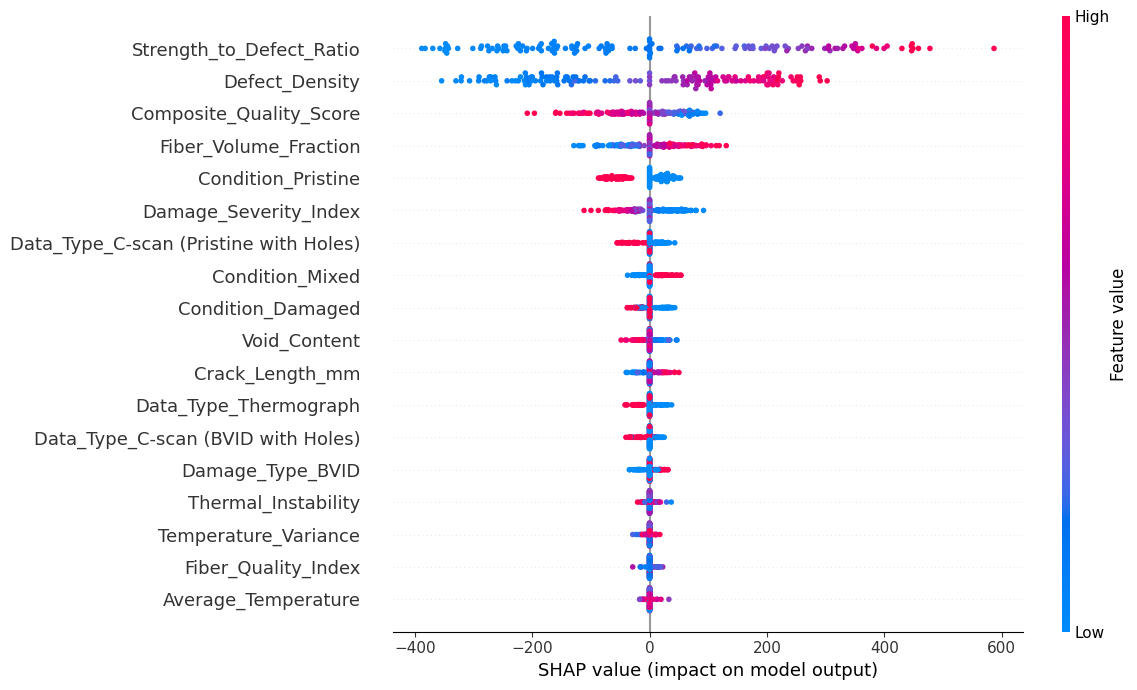

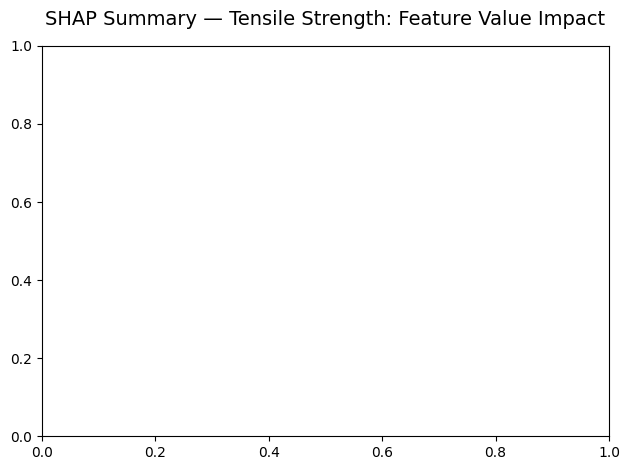

In [ ]:
# ── SHAP Beeswarm-style: Feature Value vs Impact ──────────────────
# Recreate matplotlib SHAP summary plot
shap.summary_plot(
    shap_values, explain_sample,
    feature_names=FEATURE_COLS,
    max_display=18,
    show=True,
    plot_type='dot',
    plot_size=(12, 7)
)
plt.title('SHAP Summary — Tensile Strength: Feature Value Impact', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── SHAP Waterfall: Explain a Single Prediction ───────────────────
sample_idx_explain = 5
shap_single = shap_values[sample_idx_explain]

top_n = 12
sorted_idx = np.argsort(np.abs(shap_single))[::-1][:top_n]
feats  = [FEATURE_COLS[i] for i in sorted_idx]
values = [shap_single[i] for i in sorted_idx]
colors = ['#e74c3c' if v > 0 else '#27ae60' for v in values]

baseline = ts_wrapper(background).mean()
cumulative = baseline + np.cumsum([0] + values)

fig = go.Figure(go.Waterfall(
    name='SHAP', orientation='h',
    measure=['relative'] * len(values),
    x=values[::-1],
    y=feats[::-1],
    textposition='outside',
    text=[f'{v:+.2f}' for v in values[::-1]],
    connector={'line': {'color': 'rgba(63, 63, 63, 0.5)'}},
    decreasing={'marker': {'color': '#27ae60'}},
    increasing={'marker': {'color': '#e74c3c'}},
))

actual_pred = ts_wrapper(explain_sample[sample_idx_explain:sample_idx_explain+1])[0]
fig.update_layout(
    title=f'SHAP Waterfall — Single Sample Explanation<br>'
          f'<sup>Predicted Tensile Strength: {actual_pred:.1f} MPa | '
          f'Baseline: {baseline:.1f} MPa | Red = increases prediction, Green = decreases</sup>',
    height=500, template='plotly_white',
    xaxis_title='SHAP Value (MPa impact on prediction)'
)
fig.show()

In [ ]:
# ── SHAP Dependence: Fiber Volume Fraction ────────────────────────
fvf_idx = FEATURE_COLS.index('Fiber_Volume_Fraction')

fig = px.scatter(
    x=explain_sample[:, fvf_idx],
    y=shap_values[:, fvf_idx],
    color=explain_sample[:, FEATURE_COLS.index('Void_Content')],
    color_continuous_scale='RdYlGn_r',
    labels={
        'x': 'Fiber Volume Fraction (scaled)',
        'y': 'SHAP Value (MPa impact)',
        'color': 'Void Content'
    },
    title='SHAP Dependence: Fiber Volume Fraction<br><sup>Color = Void Content — shows interaction effect</sup>',
    template='plotly_white', height=450, opacity=0.7
)
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.show()

In [ ]:
# ── Define Aerospace Thresholds ───────────────────────────────────
AEROSPACE_THRESHOLDS = {
    'aircraft': {
        'Tensile_Strength_min'   : 600,    # MPa
        'Fracture_Toughness_min' : 40,     # MPa√m
        'Defect_Density_max'     : 0.08,
        'Void_Content_max'       : 0.04,
        'Crack_Length_max'       : 1.5,    # mm
        'Structural_Integrity'   : 'High'
    },
    'spacecraft': {
        'Tensile_Strength_min'   : 700,    # MPa (stricter)
        'Fracture_Toughness_min' : 45,     # MPa√m
        'Defect_Density_max'     : 0.05,
        'Void_Content_max'       : 0.03,
        'Crack_Length_max'       : 1.0,    # mm
        'Structural_Integrity'   : 'High'
    }
}

# Use the original dataframe for screening (raw feature values)
df_screen = df.copy()

# Predict tensile strength and fracture toughness using model
# for all samples (use scaled features)
X_all = scaler.transform(
    df_ml[FEATURE_COLS].values.astype(np.float32)
).astype(np.float32)

df_screen['Predicted_Tensile_Strength'] = predict_regression(model_ts, X_all, ts_scaler)
df_screen['Predicted_Fracture_Toughness'] = predict_regression(model_ft, X_all, ft_scaler)
clf_all = predict_classification(model_clf, X_all)
df_screen['Predicted_Integrity_Class'] = class_encoder.inverse_transform(clf_all)

print(' Predictions generated for all samples')
df_screen[['Tensile_Strength', 'Predicted_Tensile_Strength',
            'Fracture_Toughness', 'Predicted_Fracture_Toughness',
            'Structural_Integrity_Class', 'Predicted_Integrity_Class']].head(10)

 Predictions generated for all samples


,Tensile_Strength,Predicted_Tensile_Strength,Fracture_Toughness,Predicted_Fracture_Toughness,Structural_Integrity_Class,Predicted_Integrity_Class
0,372.62,397.718231,31.30,30.944988,Medium,Medium
1,413.52,418.784058,49.43,49.569141,Medium,Medium
2,497.68,495.871002,34.65,34.747303,Medium,Medium
3,505.09,478.651001,31.30,30.562855,Medium,Medium
4,515.48,510.959167,59.72,45.943970,High,High
5,624.25,686.616211,39.62,39.719067,Medium,Medium
6,476.49,476.394043,37.17,37.833710,Medium,Medium
7,527.65,508.368988,33.81,33.917038,Medium,Medium
8,540.22,521.326599,23.46,33.586563,Low,Low
9,470.54,466.558136,35.87,34.294540,Medium,Medium


In [ ]:
# ── Screen Candidates Against Aerospace Requirements ──────────────
def screen_aerospace(df, thresholds, use_predicted=True):
    """Filter CFRP samples that meet aerospace requirements."""
    ts_col = 'Predicted_Tensile_Strength' if use_predicted else 'Tensile_Strength'
    ft_col = 'Predicted_Fracture_Toughness' if use_predicted else 'Fracture_Toughness'
    mask = (
        (df[ts_col]               >= thresholds['Tensile_Strength_min'])   &
        (df[ft_col]               >= thresholds['Fracture_Toughness_min']) &
        (df['Defect_Density']     <= thresholds['Defect_Density_max'])     &
        (df['Void_Content']       <= thresholds['Void_Content_max'])       &
        (df['Crack_Length_mm']    <= thresholds['Crack_Length_max'])       &
        (df['Predicted_Integrity_Class'] == thresholds['Structural_Integrity'])
    )
    return df[mask].copy()


candidates_aircraft   = screen_aerospace(df_screen, AEROSPACE_THRESHOLDS['aircraft'])
candidates_spacecraft = screen_aerospace(df_screen, AEROSPACE_THRESHOLDS['spacecraft'])

print(f'Total CFRP samples         : {len(df_screen):,}')
print(f'Aircraft-grade candidates  : {len(candidates_aircraft):,} '
      f'({100*len(candidates_aircraft)/len(df_screen):.1f}%)')
print(f'Spacecraft-grade candidates: {len(candidates_spacecraft):,} '
      f'({100*len(candidates_spacecraft)/len(df_screen):.1f}%)')

Total CFRP samples         : 8,080
Aircraft-grade candidates  : 315 (3.9%)
Spacecraft-grade candidates: 89 (1.1%)


In [ ]:
# ── Compute Composite Aerospace Score ────────────────────────────
def compute_aerospace_score(df, tier='aircraft'):
    """
    Composite score weighting key material properties for aerospace use.
    Higher = better candidate.

    Formula:
      score = w1*(norm TS) + w2*(norm FT) + w3*(1 - norm Defect) +
              w4*(1 - norm Void) + w5*(1 - norm Crack)
    """
    weights = {
        'aircraft' : {'ts': 0.35, 'ft': 0.25, 'defect': 0.20, 'void': 0.10, 'crack': 0.10},
        'spacecraft': {'ts': 0.40, 'ft': 0.30, 'defect': 0.15, 'void': 0.10, 'crack': 0.05},
    }
    w = weights[tier]

    df = df.copy()
    eps = 1e-8

    def norm(col, inverse=False):
        mn, mx = df[col].min(), df[col].max()
        n = (df[col] - mn) / (mx - mn + eps)
        return 1 - n if inverse else n

    df['Aerospace_Score'] = (
        w['ts']     * norm('Predicted_Tensile_Strength') +
        w['ft']     * norm('Predicted_Fracture_Toughness') +
        w['defect'] * norm('Defect_Density', inverse=True) +
        w['void']   * norm('Void_Content',   inverse=True) +
        w['crack']  * norm('Crack_Length_mm', inverse=True)
    ) * 100

    return df.sort_values('Aerospace_Score', ascending=False)


ranked_aircraft   = compute_aerospace_score(candidates_aircraft,   'aircraft')
ranked_spacecraft = compute_aerospace_score(candidates_spacecraft, 'spacecraft')

display_cols = [
    'Sample_ID', 'Condition', 'Fiber_Volume_Fraction', 'Void_Content',
    'Defect_Density', 'Crack_Length_mm', 'Fiber_Orientation_Degree',
    'Predicted_Tensile_Strength', 'Predicted_Fracture_Toughness',
    'Predicted_Integrity_Class', 'Aerospace_Score'
]

print('TOP 10 AIRCRAFT-GRADE CFRP CANDIDATES')
print('='*90)
print(ranked_aircraft[display_cols].head(10).round(3).to_string(index=False))

print('\n TOP 10 SPACECRAFT-GRADE CFRP CANDIDATES')
print('='*90)
print(ranked_spacecraft[display_cols].head(10).round(3).to_string(index=False))

TOP 10 AIRCRAFT-GRADE CFRP CANDIDATES
 Sample_ID Condition  Fiber_Volume_Fraction  Void_Content  Defect_Density  Crack_Length_mm  Fiber_Orientation_Degree  Predicted_Tensile_Strength  Predicted_Fracture_Toughness Predicted_Integrity_Class  Aerospace_Score
      5571  Pristine                  0.584         0.014           0.040            0.961                     25.37                  861.320007                     56.205002                      High           82.410
      5126  Pristine                  0.478         0.011           0.018            0.528                     83.92                  790.338013                     54.238998                      High           80.633
      8023  Pristine                  0.565         0.014           0.038            0.953                     57.08                  858.484009                     54.228001                      High           79.683
      2268  Pristine                  0.469         0.023           0.011            0.446

In [ ]:
# ── Aerospace Radar Chart: Top Candidates vs Thresholds ──────────
def radar_chart_aerospace(ranked_df, thresholds, title, top_n=5):
    categories = [
        'Tensile Strength', 'Fracture Toughness',
        'Low Defect Density', 'Low Void Content', 'Short Crack Length'
    ]

    def normalize_sample(row):
        return [
            min(row['Predicted_Tensile_Strength'] / 1000, 1.0),
            min(row['Predicted_Fracture_Toughness'] / 65, 1.0),
            1 - min(row['Defect_Density'] / 0.2, 1.0),
            1 - min(row['Void_Content'] / 0.1, 1.0),
            1 - min(row['Crack_Length_mm'] / 5, 1.0)
        ]

    fig = go.Figure()

    # Threshold line
    thresh_vals = [
        thresholds['Tensile_Strength_min'] / 1000,
        thresholds['Fracture_Toughness_min'] / 65,
        1 - thresholds['Defect_Density_max'] / 0.2,
        1 - thresholds['Void_Content_max'] / 0.1,
        1 - thresholds['Crack_Length_max'] / 5
    ]
    fig.add_trace(go.Scatterpolar(
        r=thresh_vals + [thresh_vals[0]],
        theta=categories + [categories[0]],
        fill='toself', fillcolor='rgba(255,0,0,0.1)',
        line=dict(color='red', width=2, dash='dash'),
        name='Min Threshold'
    ))

    colors = ['#27ae60', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']
    for i, (_, row) in enumerate(ranked_df.head(top_n).iterrows()):
        vals = normalize_sample(row)
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]],
            theta=categories + [categories[0]],
            fill='toself', fillcolor=f'rgba{tuple(int(colors[i][j:j+2],16) for j in (1,3,5)) + (0.2,)}',
            line=dict(color=colors[i], width=2),
            name=f'Sample {int(row["Sample_ID"])} (Score:{row["Aerospace_Score"]:.1f})'
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title=title, height=550, template='plotly_white'
    )
    return fig


fig_aircraft = radar_chart_aerospace(
    ranked_aircraft,
    AEROSPACE_THRESHOLDS['aircraft'],
    'Radar Chart — Top Aircraft-Grade CFRP Candidates vs Threshold'
)
fig_aircraft.show()

fig_spacecraft = radar_chart_aerospace(
    ranked_spacecraft,
    AEROSPACE_THRESHOLDS['spacecraft'],
    'Radar Chart — Top Spacecraft-Grade CFRP Candidates vs Threshold'
)
fig_spacecraft.show()

In [ ]:
# ── Aerospace Score Distribution ──────────────────────────────────
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Aircraft-Grade Score Distribution',
                                    'Spacecraft-Grade Score Distribution'])

fig.add_trace(go.Histogram(
    x=ranked_aircraft['Aerospace_Score'], nbinsx=40,
    marker_color='steelblue', opacity=0.8, name='Aircraft'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=ranked_spacecraft['Aerospace_Score'], nbinsx=40,
    marker_color='coral', opacity=0.8, name='Spacecraft'
), row=1, col=2)

fig.update_layout(
    title='Aerospace Score Distribution of Qualifying CFRP Samples',
    height=420, template='plotly_white', showlegend=False
)
fig.show()

In [ ]:
# ── Fiber Orientation Optimization Analysis ───────────────────────
# How does fiber orientation angle affect tensile strength for candidates?
fig = make_subplots(rows=1, cols=2,
    subplot_titles=[
        'Aircraft: Fiber Orientation vs Predicted Tensile Strength',
        'Spacecraft: Fiber Orientation vs Predicted Tensile Strength'
    ])

for col_idx, (df_cand, label, color) in enumerate([
    (ranked_aircraft,   'Aircraft',   '#3498db'),
    (ranked_spacecraft, 'Spacecraft', '#e74c3c')
], start=1):
    fig.add_trace(go.Scatter(
        x=df_cand['Fiber_Orientation_Degree'],
        y=df_cand['Predicted_Tensile_Strength'],
        mode='markers',
        marker=dict(
            color=df_cand['Aerospace_Score'],
            colorscale='Viridis', size=7, opacity=0.8,
            showscale=(col_idx == 2),
            colorbar=dict(title='Score')
        ),
        name=label
    ), row=1, col=col_idx)

fig.update_xaxes(title_text='Fiber Orientation Angle (°)')
fig.update_yaxes(title_text='Predicted Tensile Strength (MPa)', row=1, col=1)
fig.update_layout(
    title=' Fiber Orientation Optimization — Effect on Tensile Strength',
    height=450, template='plotly_white'
)
fig.show()

In [ ]:
# ── Model-Based Composition Optimization ─────────────────────────
# Sweep fiber volume fraction and void content to find optimal region
print('Running composition sweep optimization...')

fvf_range  = np.linspace(0.45, 0.70, 30)
void_range = np.linspace(0.01, 0.08, 30)

# Build a grid of synthetic CFRP samples
# Hold other features at optimal values from top spacecraft candidates
top_spacecraft = ranked_spacecraft.iloc[0]

grid_records = []
for fvf in fvf_range:
    for vc in void_range:
        record = df_ml[FEATURE_COLS].iloc[0].copy() * 0  # zeros base
        record['Fiber_Volume_Fraction'] = fvf
        record['Void_Content']          = vc
        record['Defect_Density']        = 0.03      # optimal low defect
        record['Crack_Length_mm']       = 0.5       # optimal short crack
        record['Fiber_Orientation_Degree'] = 45     # quasi-isotropic
        record['Average_Temperature']   = top_spacecraft['Average_Temperature']
        record['Temperature_Variance']  = 5.0
        record['Fracture_Toughness']    = top_spacecraft['Fracture_Toughness']
        record['LBP_Feature_1']         = 0.5
        record['LBP_Feature_2']         = 0.5
        record['Texture_Contrast']      = 0.5
        record['Vent_Holes']            = 3
        # Engineered features
        record['Strength_to_Defect_Ratio'] = 0
        record['Toughness_per_Crack']      = 0
        record['Fiber_Quality_Index']      = fvf / (vc + 1e-5)
        record['Damage_Severity_Index']    = 0.03 * 0.5
        record['Thermal_Instability']      = record['Average_Temperature'] * 5.0
        record['Composite_Quality_Score']  = fvf - vc - 0.03
        grid_records.append({'FVF': fvf, 'Void': vc, **record.to_dict()})

grid_df = pd.DataFrame(grid_records)

# Predict tensile strength for the grid
X_grid = scaler.transform(grid_df[FEATURE_COLS].values.astype(np.float32)).astype(np.float32)
grid_df['Predicted_TS'] = predict_regression(model_ts, X_grid, ts_scaler)

# Pivot for heatmap
pivot = grid_df.pivot_table(
    index='Void', columns='FVF', values='Predicted_TS'
)

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=[f'{v:.2f}' for v in pivot.columns],
    y=[f'{v:.3f}' for v in pivot.index],
    colorscale='RdYlGn',
    colorbar=dict(title='Predicted Tensile<br>Strength (MPa)'),
    hoverongaps=False
))

# Mark the spacecraft threshold
fig.add_shape(type='rect',
    x0=-0.5, x1=29.5,
    y0=pivot.index.tolist().index(
        min(pivot.index, key=lambda x: abs(x - 0.03))
    ) - 0.5,
    y1=0.5,
    fillcolor='rgba(0,0,255,0.1)',
    line=dict(color='blue', width=2)
)

fig.update_layout(
    title='Composition Optimization Map<br>'
          '<sup>Fiber Volume Fraction vs Void Content → Predicted Tensile Strength (MPa) | '
          'Green = Strong | Red = Weak</sup>',
    xaxis_title='Fiber Volume Fraction',
    yaxis_title='Void Content',
    height=550, template='plotly_white'
)
fig.show()

# Best combination
best = grid_df.loc[grid_df['Predicted_TS'].idxmax()]
print(f'\nOptimal Composition for Spacecraft CFRP:')
print(f'   Fiber Volume Fraction : {best["FVF"]:.3f}')
print(f'   Void Content          : {best["Void"]:.4f}')
print(f'   Predicted TS          : {best["Predicted_TS"]:.1f} MPa')

Running composition sweep optimization...



Optimal Composition for Spacecraft CFRP:
   Fiber Volume Fraction : 0.510
   Void Content          : 0.0390
   Predicted TS          : 82.5 MPa


In [ ]:
# ── Waterfall: Pass/Fail Analysis for All Samples ─────────────────
df_screen['Passes_Aircraft']   = df_screen.index.isin(ranked_aircraft.index)
df_screen['Passes_Spacecraft'] = df_screen.index.isin(ranked_spacecraft.index)
df_screen['Category'] = 'Neither'
df_screen.loc[df_screen['Passes_Aircraft'],   'Category'] = 'Aircraft Only'
df_screen.loc[df_screen['Passes_Spacecraft'], 'Category'] = 'Aircraft + Spacecraft'

cat_counts = df_screen['Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']

fig = px.bar(
    cat_counts, x='Category', y='Count',
    color='Category',
    color_discrete_map={
        'Neither': '#e74c3c',
        'Aircraft Only': '#3498db',
        'Aircraft + Spacecraft': '#27ae60'
    },
    title='CFRP Qualification Results — How Many Samples Pass Aerospace Standards?',
    text='Count', template='plotly_white', height=420
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
# ── Summary: Why Top Spacecraft Candidate Qualifies (SHAP Explanation) ─
print('='*65)
print('EXPLAINING TOP SPACECRAFT-GRADE CFRP SAMPLE')
print('='*65)

best_sc_id  = ranked_spacecraft.index[0]
best_sc_row = df_screen.loc[best_sc_id]

print(f"\nSample ID         : {int(best_sc_row['Sample_ID'])}")
print(f"Condition         : {best_sc_row['Condition']}")
print(f"Fiber Vol. Frac.  : {best_sc_row['Fiber_Volume_Fraction']:.3f}")
print(f"Void Content      : {best_sc_row['Void_Content']:.4f}")
print(f"Defect Density    : {best_sc_row['Defect_Density']:.4f}")
print(f"Crack Length (mm) : {best_sc_row['Crack_Length_mm']:.3f}")
print(f"Fiber Orientation : {best_sc_row['Fiber_Orientation_Degree']:.1f}°")
print(f"Avg Temperature   : {best_sc_row['Average_Temperature']:.1f}°C")
print(f"Actual TS         : {best_sc_row['Tensile_Strength']:.1f} MPa")
print(f"Predicted TS      : {best_sc_row['Predicted_Tensile_Strength']:.1f} MPa")
print(f"Actual FT         : {best_sc_row['Fracture_Toughness']:.2f} MPa√m")
print(f"Predicted FT      : {best_sc_row['Predicted_Fracture_Toughness']:.2f} MPa√m")
print(f"Integrity Class   : {best_sc_row['Predicted_Integrity_Class']}")
print(f"Aerospace Score   : {ranked_spacecraft.loc[best_sc_id, 'Aerospace_Score']:.2f}/100")

print('\nThis sample qualifies for SPACECRAFT use because:')
t = AEROSPACE_THRESHOLDS['spacecraft']
print(f'   ✓ Tensile Strength {best_sc_row["Predicted_Tensile_Strength"]:.0f} MPa ≥ {t["Tensile_Strength_min"]} MPa')
print(f'   ✓ Fracture Toughness {best_sc_row["Predicted_Fracture_Toughness"]:.1f} MPa√m ≥ {t["Fracture_Toughness_min"]} MPa√m')
print(f'   ✓ Defect Density {best_sc_row["Defect_Density"]:.4f} ≤ {t["Defect_Density_max"]}')
print(f'   ✓ Void Content {best_sc_row["Void_Content"]:.4f} ≤ {t["Void_Content_max"]}')
print(f'   ✓ Crack Length {best_sc_row["Crack_Length_mm"]:.3f} mm ≤ {t["Crack_Length_max"]} mm')
print(f'   ✓ Structural Integrity: High')

EXPLAINING TOP SPACECRAFT-GRADE CFRP SAMPLE

Sample ID         : 5571
Condition         : Pristine
Fiber Vol. Frac.  : 0.584
Void Content      : 0.0140
Defect Density    : 0.0400
Crack Length (mm) : 0.961
Fiber Orientation : 25.4°
Avg Temperature   : 108.9°C
Actual TS         : 890.3 MPa
Predicted TS      : 861.3 MPa
Actual FT         : 58.61 MPa√m
Predicted FT      : 56.21 MPa√m
Integrity Class   : High
Aerospace Score   : 80.45/100

This sample qualifies for SPACECRAFT use because:
   ✓ Tensile Strength 861 MPa ≥ 700 MPa
   ✓ Fracture Toughness 56.2 MPa√m ≥ 45 MPa√m
   ✓ Defect Density 0.0400 ≤ 0.05
   ✓ Void Content 0.0140 ≤ 0.03
   ✓ Crack Length 0.961 mm ≤ 1.0 mm
   ✓ Structural Integrity: High
